# Replicating Gorman & Sejnowski's Sonar Target Classifier

This notebook follows the experiment from **Gorman and Sejnowski (1988), _Analysis of Hidden Units in a Layered Network Trained to Classify Sonar Targets_**. The paper studies whether a small layered neural network can distinguish sonar returns from two object types: a metal cylinder, used as a mine-like target, and a similarly shaped rock.

Paper: https://papers.cnl.salk.edu/PDFs/Analysis%20of%20Hidden%20Units%20in%20a%20Layered%20Network%20Trained%20to%20Classify%20Sonar%20Targets%201988-2996.pdf

## Dataset Overview

We use the UCI **Connectionist Bench (Sonar, Mines vs. Rocks)** dataset. It contains 208 sonar patterns, each represented by 60 real-valued measurements. Each measurement is the energy in a particular frequency band after a frequency-modulated chirp signal reflects from an object.

The target label is binary:

- `R`: sonar signal reflected from a rock
- `M`: sonar signal reflected from a metal cylinder / mine-like object

The dataset has 97 rock examples and 111 metal-cylinder examples. The goal is to train a classifier that maps the 60-dimensional sonar signature to one of these two classes.


## 0. Environment Setup

This section installs the UCI dataset helper used to download the Sonar dataset directly inside the notebook.


In [ ]:
!pip install ucimlrepo

## 1. Data Analysis

We first load the raw features and labels, inspect the dataset shape, check the class balance, and preview a few rows. This gives us a quick sanity check before converting the data into tensors.


In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

sonar_dataset  = fetch_ucirepo(id=151)
X = sonar_dataset.data.features
y = sonar_dataset.data.targets

print("Dataset:", sonar_dataset.metadata["name"])
print("Samples:", X.shape[0])
print("Features:", X.shape[1])

print("\nTarget distribution:")
display(y.value_counts().reset_index(name="count"))

print("\nFeature preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())

Dataset: Connectionist Bench (Sonar, Mines vs. Rocks)
Samples: 208
Features: 60

Target distribution:


,class,count
0,M,111
1,R,97



Feature preview:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094



Target preview:


,class
0,R
1,R
2,R
3,R
4,R


### 1.1 Class Balance

The target distribution is important because the dataset is small. A large imbalance would make accuracy less informative, but here the two classes are close enough for a simple first-pass comparison.


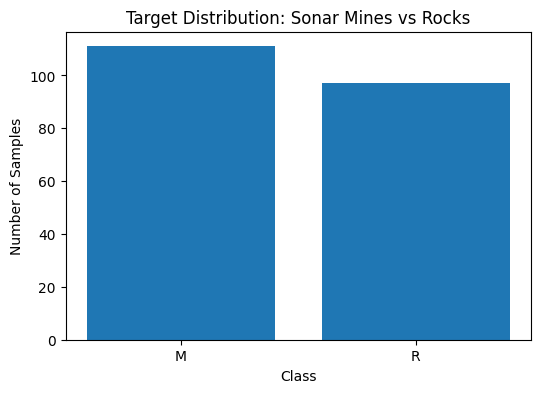

In [ ]:
import matplotlib.pyplot as plt

target_counts = y.iloc[:, 0].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values)

plt.title("Target Distribution: Sonar Mines vs Rocks")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

## 2. Dataset Handling

Next we wrap the UCI data in a PyTorch `Dataset`. The 60 sonar attributes become `float32` tensors, while the string labels are encoded as integer classes: `0` for rock and `1` for metal cylinder / mine.


In [ ]:
import torch
from torch.utils.data import Dataset

class SonarDataset(Dataset):
    def __init__(self):
        sonar_dataset = fetch_ucirepo(id=151)

        X = sonar_dataset.data.features
        y = sonar_dataset.data.targets

        self.X = torch.tensor(X.values, dtype=torch.float32)

        y = y.iloc[:, 0].map({
            "R": 0,
            "M": 1
        })

        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

### 2.1 Dataset Sanity Check

This random sample check confirms that the dataset returns one feature vector of length 60 together with one encoded class label.


In [ ]:
import random

dataset = SonarDataset()

random_index = random.randint(0, len(dataset) - 1)

x_sample, y_sample = dataset[random_index]

label_names = {
    0: "Rock",
    1: "Mine / Metal"
}

label_text = label_names[y_sample.item()]

print("=" * 60)
print("Random Sonar Dataset Sample")
print("=" * 60)

print(f"Sample index: {random_index}")
print(f"Feature vector shape: {x_sample.shape}")
print(f"Target label: {y_sample.item()} ({label_text})")

print("-" * 60)
print("First 10 feature values:")
print(x_sample[:10])

print("-" * 60)
print("Full feature vector:")
print(x_sample)

print("=" * 60)

Random Sonar Dataset Sample
Sample index: 152
Feature vector shape: torch.Size([60])
Target label: 1 (Mine / Metal)
------------------------------------------------------------
First 10 feature values:
tensor([0.0131, 0.0201, 0.0045, 0.0217, 0.0230, 0.0481, 0.0742, 0.0333, 0.1369,
        0.2079])
------------------------------------------------------------
Full feature vector:
tensor([0.0131, 0.0201, 0.0045, 0.0217, 0.0230, 0.0481, 0.0742, 0.0333, 0.1369,
        0.2079, 0.2295, 0.1990, 0.1184, 0.1891, 0.2949, 0.5343, 0.6850, 0.7923,
        0.8220, 0.7290, 0.7352, 0.7918, 0.8057, 0.4898, 0.1934, 0.2924, 0.6255,
        0.8546, 0.8966, 0.7821, 0.5168, 0.4840, 0.4038, 0.3411, 0.2849, 0.2353,
        0.2699, 0.4442, 0.4323, 0.3314, 0.1195, 0.1669, 0.3702, 0.3072, 0.0945,
        0.1545, 0.1394, 0.0772, 0.0615, 0.0230, 0.0111, 0.0168, 0.0086, 0.0045,
        0.0062, 0.0065, 0.0030, 0.0066, 0.0029, 0.0053])


## 3. Model Architecture

The paper used a compact layered network with 60 input units, 12 hidden units, and 2 output units. We mirror that structure with a feed-forward PyTorch model: one hidden layer with a sigmoid activation followed by a two-logit output layer.


In [ ]:
import torch
import torch.nn as nn

class SonarFFNN(nn.Module):
    """
    Feed-forward neural network for Sonar Mines vs Rocks classification.

    Architecture inspired by Gorman & Sejnowski (1988):
        60 input units -> 12 hidden units -> 2 output units
    """

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(60, 12),
            nn.Sigmoid(),
            nn.Linear(12, 2)
        )

    def forward(self, x):
        return self.network(x)


## 4. Training Configuration

These constants keep the training choices in one place: number of epochs, learning rate, batch size, data split, and data-loading behavior.


In [ ]:
NUM_EPOCHS = 1500
LR = 0.1
NUM_WORKERS = 0
TRAIN_TEST_SPLIT = 0.8
BATCH_SIZE = 16

## 5. Train/Test Split and DataLoaders

We create a reproducible 80/20 train/test split, then build PyTorch `DataLoader` objects for minibatch training and evaluation.


In [ ]:
import torch
from torch.utils.data import random_split, DataLoader

dataset = SonarDataset()
torch.manual_seed(42)

train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Total samples: 208
Training samples: 166
Testing samples: 42


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

## 6. Training Setup

Here we choose the available device, instantiate the model, define the cross-entropy loss, and configure stochastic gradient descent.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = SonarFFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

Using device: cuda


## 7. Reusable Training Function

Before training the baseline model, we define a reusable function. This lets us train the original architecture and any improved FFNN architecture with the same loop, logging, and optional learning-rate scheduler support.


In [ ]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    scheduler=None,
    log_every=25
):
    history = {
        "train_loss": [],
        "train_accuracy": []
    }

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

            predicted_classes = outputs.argmax(dim=1)
            correct_train += (predicted_classes == y_batch).sum().item()
            total_train += y_batch.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss / total_train
        train_accuracy =  correct_train / total_train

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        if (epoch + 1) % log_every == 0 or epoch == 0:
            print("=" * 60)
            print(f"Epoch [{epoch + 1:03d}/{num_epochs}]")
            print("-" * 60)
            print(f"Training Loss:     {train_loss:.4f}")
            print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

    return history


## 8. Model Training

Now we train the baseline model by calling the reusable training function. Because the dataset is small, training accuracy can become very high; the final test evaluation is the more useful check of generalization.


In [ ]:
baseline_history = train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    log_every=25
)

Epoch [001/1500]
------------------------------------------------------------
Training Loss:     0.7070
Training Accuracy: 50.60%
Epoch [025/1500]
------------------------------------------------------------
Training Loss:     0.6811
Training Accuracy: 56.63%
Epoch [050/1500]
------------------------------------------------------------
Training Loss:     0.6371
Training Accuracy: 65.06%
Epoch [075/1500]
------------------------------------------------------------
Training Loss:     0.5557
Training Accuracy: 73.49%
Epoch [100/1500]
------------------------------------------------------------
Training Loss:     0.4955
Training Accuracy: 76.51%
Epoch [125/1500]
------------------------------------------------------------
Training Loss:     0.4498
Training Accuracy: 80.72%
Epoch [150/1500]
------------------------------------------------------------
Training Loss:     0.4202
Training Accuracy: 78.92%
Epoch [175/1500]
------------------------------------------------------------
Training Los

## 9. Final Evaluation

Finally, we evaluate the trained model on the held-out test split. This gives a simple estimate of how well the replicated architecture generalizes beyond the training examples.


In [ ]:
model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        test_loss_sum += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)
        test_correct += (predictions == y_batch).sum().item()
        test_total += y_batch.size(0)

test_loss = test_loss_sum / test_total
test_accuracy = test_correct / test_total

print("=" * 60)
print("Final Test Evaluation")
print("=" * 60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("=" * 60)

Final Test Evaluation
Test Loss:     0.3369
Test Accuracy: 83.33%


## 10. Class Task: Improve the FFNN

The model above recreates the small feed-forward architecture inspired by the original paper. Your task is to improve the classifier while still using only a feed-forward neural network.

Try changing one thing at a time and compare the final test accuracy with the baseline result.

### Tasks

1. Add more hidden layers or change the number of neurons in each layer.
2. Read what the sigmoid activation does, then try alternatives such as `ReLU`, `GELU`, `Tanh`, or others from the PyTorch activation layers: https://docs.pytorch.org/docs/main/nn.html
3. Optional: read what learning-rate schedulers are and try one from PyTorch: https://docs.pytorch.org/docs/2.12/generated/torch.optim.lr_scheduler.LRScheduler.html
4. Save your best model after training.

Keep notes about what you changed and whether it improved the test result.


### 10.1 Improved Architecture

Define a new FFNN architecture here. You can start by adding more hidden layers, changing the hidden sizes, or replacing `Sigmoid` with another activation function.


In [ ]:
class ImprovedSonarFFNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
        )

    def forward(self, x):
        return self.network(x)


### 10.2 Train the Improved Model

Create a new model, optimizer, and optionally a learning-rate scheduler. Reuse the existing `train_loader`, `test_loader`, `criterion`, and training logic as a starting point.


In [ ]:
improved_model = ImprovedSonarFFNN().to(device)
improved_optimizer = torch.optim.SGD(improved_model.parameters(), lr=LR)

# Optional scheduler example:
# scheduler = torch.optim.lr_scheduler.StepLR(improved_optimizer, step_size=300, gamma=0.5)

improved_history = train_model(
    model=improved_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=improved_optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    scheduler=None,  # Replace with scheduler if you create one above.
    log_every=25
)


### 10.3 Save the Best Model

After training and evaluating your improved model, save its parameters so the model can be loaded again later without retraining.


In [ ]:
torch.save(improved_model.state_dict(), "improved_sonar_ffnn.pt")
